# Lightweight 1DConv + FiLM (metadata) -> MLP head

In [1]:
import os, sys, time
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (balanced_accuracy_score, f1_score, classification_report,
                             confusion_matrix, matthews_corrcoef, precision_recall_curve,
                             average_precision_score, roc_auc_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# Function to find project root
# exit if not found
def find_project_root(name='Bambino', start=None):
    if start is None:
        start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name:
            return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir:
            return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
print('Detected project root:', PROJECT_ROOT)
try:
    sys.path.append(PROJECT_ROOT)
    print("Added project root to sys.path.")
except Exception as e:
    print("Failed to add project root to sys.path:", e)
    sys.exit(1)

from config import settings
import config_film as cfg
# Try to import your BoaOpenFaceDataset (adjust PYTHONPATH as needed)
try:
    from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
    print("Loaded BoaOpenFaceDataset.")
except Exception as e:
    raise ImportError("Could not import BoaOpenFaceDataset - run this from repo root or adjust PYTHONPATH.") from e

from _utils_ import dataset_utils
print("Loaded project config and BoaOpenFaceDataset from repo (using utils.get_dataset_path).")
USE_PROJECT_UTILS = True

# Paths: if utils is available, use its helper; otherwise set manual paths
if USE_PROJECT_UTILS:
    TRAIN_PATH = settings.get_dataset_path(cfg.dataset_type, settings.training_filename)
    VAL_PATH = settings.get_dataset_path(cfg.dataset_type, settings.validation_filename)
    TEST_PATH = settings.get_dataset_path(cfg.dataset_type, settings.test_filename)
else:
    TRAIN_PATH = ""
    VAL_PATH = ""
    TEST_PATH = ""

OUT_DIR = Path("./results_FiLM")
OUT_DIR.mkdir(parents=True, exist_ok=True)

Detected project root: /home/phd2/Scrivania/CorsoRepo/Bambino
Added project root to sys.path.
Loaded BoaOpenFaceDataset.
Loaded project config and BoaOpenFaceDataset from repo (using utils.get_dataset_path).


In [2]:
# Model / training config
TARGET_LEN = cfg.TARGET_LEN          # target temporal length (pad/truncate to this)
BATCH_SIZE = cfg.BATCH_SIZE
NUM_EPOCHS = cfg.NUM_EPOCHS
LR = cfg.LR
WEIGHT_DECAY = cfg.WEIGHT_DECAY
PATIENCE = cfg.PATIENCE              # early stopping epochs on val balanced accuracy
DEVICE = cfg.DEVICE
PRINT_EVERY = cfg.PRINT_EVERY

# Modalities to use (g,h,f as in your project)
MODALITIES = cfg.MODALITIES

# Numeric and categorical metadata fields (same as earlier pipeline)
numeric_features = cfg.numeric_features
cat_features = cfg.cat_features

In [3]:
# ---------- Helpers: dataset conversion, padding, normalization ----------
def ds_to_numpy_and_meta(ds, modalities=MODALITIES, target_len=TARGET_LEN):
    """
    Convert BoaOpenFaceDataset ds -> (X_ts [N,C,L], meta_rows list-of-dicts, keys list)
    We build metadata rows for each instance (age, sex, audio, speaker, duration)
    We pad/truncate sequences to target_len (time dimension).
    Order of samples follows ds.instances.
    """
    modality_map = {'g': 'gaze_info', 'h': 'head_info', 'f': 'face_info'}
    X_list, metas, keys = [], [], []
    for inst in ds.instances:
        mats = []
        for m in modalities:
            attr = modality_map[m]
            mat = getattr(inst, attr)  # expected shape [L, Dm]
            mats.append(np.asarray(mat))
        X = np.concatenate(mats, axis=1)  # [L, D_tot]
        L = X.shape[0]
        # pad or truncate along time dimension to target_len
        if L >= target_len:
            # center crop if longer
            start = (L - target_len) // 2
            X_t = X[start:start+target_len, :]
        else:
            pad = np.zeros((target_len - L, X.shape[1]), dtype=X.dtype)
            X_t = np.vstack([X, pad])
        X_list.append(X_t.T)  # [C, L]
        # metadata
        try:
            age = float(inst.age) if inst.age is not None else np.nan
        except:
            age = np.nan
        duration_s = X.shape[0] / getattr(ds, "FRAME_RATE", 25)
        meta_row = {
            'pt_id': inst.pt_id,
            'trial_id': inst.trial_id,
            'label': int(inst.trial_type),
            'age': age,
            'sex': inst.sex if hasattr(inst, 'sex') else np.nan,
            'audio': inst.audio if hasattr(inst, 'audio') else None,
            'speaker': inst.speaker if hasattr(inst, 'speaker') else None,
            'duration_s': duration_s
        }
        metas.append(meta_row)
        keys.append((str(inst.pt_id), int(inst.trial_id)))
    X_arr = np.stack(X_list, axis=0)  # [N, C, L]
    meta_df = pd.DataFrame(metas)
    return X_arr.astype(np.float32), meta_df, keys

# Normalization: compute channel-wise mean/std on training set and apply to all splits
def compute_channel_norm(X_train):  # X_train [N,C,L]
    mean = X_train.mean(axis=(0,2))  # per channel
    std  = X_train.std(axis=(0,2))
    std[std==0] = 1.0
    return mean, std

def apply_channel_norm(X, mean, std):
    # X [N,C,L]
    Xn = (X - mean[None,:,None]) / std[None,:,None]
    return Xn


In [4]:

# %% Load datasets and convert
print("Loading datasets...")
train_ds = BoaOpenFaceDataset.load_dataset(TRAIN_PATH)
val_ds   = BoaOpenFaceDataset.load_dataset(VAL_PATH)
test_ds  = BoaOpenFaceDataset.load_dataset(TEST_PATH)
print("Instances:", len(train_ds), len(val_ds), len(test_ds))

X_train_ts, df_train_meta, keys_train = ds_to_numpy_and_meta(train_ds, MODALITIES, TARGET_LEN)
X_val_ts,   df_val_meta,   keys_val   = ds_to_numpy_and_meta(val_ds, MODALITIES, TARGET_LEN)
X_test_ts,  df_test_meta,  keys_test  = ds_to_numpy_and_meta(test_ds, MODALITIES, TARGET_LEN)

y_train = df_train_meta['label'].values
y_val   = df_val_meta['label'].values
y_test  = df_test_meta['label'].values

print("Shapes (N, C, L):", X_train_ts.shape, X_val_ts.shape, X_test_ts.shape)

# Compute channel normalization from train and apply
ch_mean, ch_std = compute_channel_norm(X_train_ts)
X_train_ts = apply_channel_norm(X_train_ts, ch_mean, ch_std)
X_val_ts   = apply_channel_norm(X_val_ts, ch_mean, ch_std)
X_test_ts  = apply_channel_norm(X_test_ts, ch_mean, ch_std)

# Build metadata preprocessor and transform
meta_preproc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='drop'
)

# Fit on training meta
meta_preproc.fit(df_train_meta[numeric_features + cat_features])
X_meta_train = meta_preproc.transform(df_train_meta[numeric_features + cat_features])
X_meta_val   = meta_preproc.transform(df_val_meta[numeric_features + cat_features])
X_meta_test  = meta_preproc.transform(df_test_meta[numeric_features + cat_features])

meta_dim = X_meta_train.shape[1]
ts_in_channels = X_train_ts.shape[1]
print("meta_dim:", meta_dim, "ts_in_channels:", ts_in_channels)

# Save preprocessor for later
joblib.dump(meta_preproc, OUT_DIR/"meta_preproc.joblib")


Loading datasets...
Instances: 985 140 137
Shapes (N, C, L): (985, 38, 250) (140, 38, 250) (137, 38, 250)
meta_dim: 4 ts_in_channels: 38


['results_FiLM/meta_preproc.joblib']

In [5]:
# %% Build PyTorch Datasets / Dataloaders
def build_loader(X_ts, X_meta, y, batch_size=BATCH_SIZE, shuffle=True):
    # convert to torch tensors
    tX_ts = torch.tensor(X_ts, dtype=torch.float32)           # [N,C,L]
    tX_meta = torch.tensor(X_meta, dtype=torch.float32)      # [N,meta_dim]
    ty = torch.tensor(y, dtype=torch.float32)                # [N]
    ds = TensorDataset(tX_ts, tX_meta, ty)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)
    return loader

train_loader = build_loader(X_train_ts, X_meta_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = build_loader(X_val_ts, X_meta_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = build_loader(X_test_ts, X_meta_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

In [6]:

# %% Define model with FiLM
class ConvFiLM(nn.Module):
    def __init__(self, in_channels, meta_dim, channels=(64,128), kernel_size=5, dropout=0.2):
        super().__init__()
        ch1, ch2 = channels
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels, ch1, kernel_size=kernel_size, padding=pad)
        self.bn1 = nn.BatchNorm1d(ch1)
        self.conv2 = nn.Conv1d(ch1, ch2, kernel_size=kernel_size, padding=pad)
        self.bn2 = nn.BatchNorm1d(ch2)
        # FiLM MLPs: produce gamma and beta for each conv channel
        self.film1 = nn.Sequential(nn.Linear(meta_dim, ch1*2), nn.ReLU())
        self.film2 = nn.Sequential(nn.Linear(meta_dim, ch2*2), nn.ReLU())
        self.pool = nn.AdaptiveAvgPool1d(1)
        # head: combine pooled conv features + metadata
        head_in = ch2 + meta_dim
        self.head = nn.Sequential(
            nn.Linear(head_in, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)  # output logit
        )

    def forward(self, x_ts, x_meta):
        # x_ts: [B, C, L], x_meta: [B, meta_dim]
        # Conv1 + FiLM1
        x = self.conv1(x_ts)
        x = self.bn1(x)
        x = torch.relu(x)
        # FiLM parameters
        film1_params = self.film1(x_meta)  # [B, ch1*2]
        gamma1, beta1 = film1_params.chunk(2, dim=1)  # each [B, ch1]
        gamma1 = gamma1.unsqueeze(-1)  # [B, ch1, 1]
        beta1 = beta1.unsqueeze(-1)
        x = gamma1 * x + beta1

        # Conv2 + FiLM2
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        film2_params = self.film2(x_meta)
        gamma2, beta2 = film2_params.chunk(2, dim=1)
        gamma2 = gamma2.unsqueeze(-1)
        beta2 = beta2.unsqueeze(-1)
        x = gamma2 * x + beta2

        # Pooling
        x = self.pool(x).squeeze(-1)  # [B, ch2]
        # concat meta
        xcat = torch.cat([x, x_meta], dim=1)
        logit = self.head(xcat).squeeze(-1)
        return logit

# Instantiate model
model = ConvFiLM(in_channels=ts_in_channels, meta_dim=meta_dim, channels=(64,128), kernel_size=5, dropout=0.2)
model = model.to(DEVICE)
print(model)

ConvFiLM(
  (conv1): Conv1d(38, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (film1): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
  )
  (film2): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): ReLU()
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (head): Sequential(
    (0): Linear(in_features=132, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [7]:

# %% Loss, optimizer
# Compute pos weight for BCE (pos_weight = neg/pos)
pos = int((y_train==1).sum())
neg = int((y_train==0).sum())
pos_weight = torch.tensor(max(1.0, neg / max(1.0, pos)), dtype=torch.float32).to(DEVICE)
print("pos, neg:", pos, neg, "pos_weight:", float(pos_weight))

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)



pos, neg: 497 488 pos_weight: 1.0


Starting training on device: cuda
Epoch 01 | train_loss=0.6967 | val_bal=0.4598 | val_bce=0.6927 | val_focal=0.0608 | val_brier=0.2498 | time=0.4s
Epoch 02 | train_loss=0.6948 | val_bal=0.5000 | val_bce=0.6879 | val_focal=0.0605 | val_brier=0.2474 | time=0.1s
Epoch 03 | train_loss=0.6936 | val_bal=0.5536 | val_bce=0.6911 | val_focal=0.0607 | val_brier=0.2490 | time=0.1s
Epoch 04 | train_loss=0.6934 | val_bal=0.4866 | val_bce=0.6858 | val_focal=0.0608 | val_brier=0.2463 | time=0.1s
Epoch 05 | train_loss=0.6866 | val_bal=0.5179 | val_bce=0.6268 | val_focal=0.0640 | val_brier=0.2171 | time=0.1s
Epoch 06 | train_loss=0.6582 | val_bal=0.4866 | val_bce=0.7986 | val_focal=0.0936 | val_brier=0.2993 | time=0.1s
Epoch 07 | train_loss=0.5862 | val_bal=0.5223 | val_bce=0.6036 | val_focal=0.1963 | val_brier=0.1889 | time=0.1s
Epoch 08 | train_loss=0.5044 | val_bal=0.5312 | val_bce=0.7280 | val_focal=0.2294 | val_brier=0.2294 | time=0.1s
Epoch 09 | train_loss=0.4464 | val_bal=0.4688 | val_bce=0.7573

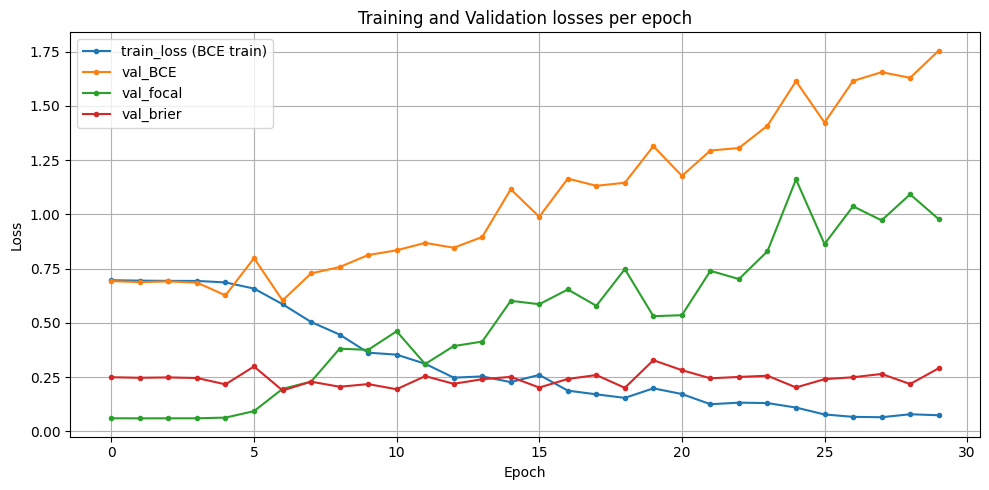

In [8]:
# ---------- Replacement training loop: track train loss + multiple val losses (BCE, Focal, Brier) ----------
import time
import torch
import numpy as np
from sklearn.metrics import brier_score_loss, balanced_accuracy_score

# Focal loss (PyTorch, logits input)
def focal_loss_torch(logits, targets, alpha=0.25, gamma=2.0, reduction='mean'):
    """
    logits: torch tensor (B,) raw logits
    targets: torch tensor (B,) with values {0,1}
    """
    probs = torch.sigmoid(logits)
    targets = targets.float()
    # BCE per-sample
    ce = torch.nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    # p_t = p if y==1 else 1-p
    p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
    loss = ce * ((1.0 - p_t) ** gamma)
    alpha_t = alpha * targets + (1.0 - alpha) * (1.0 - targets)
    loss = alpha_t * loss
    if reduction == 'mean':
        return loss.mean()
    elif reduction == 'sum':
        return loss.sum()
    else:
        return loss

# New eval that returns logits tensor (on DEVICE), probs (numpy) and labels (numpy)
def eval_model_logits_probs(model, loader):
    model.eval()
    logits_list = []
    labels_list = []
    with torch.no_grad():
        for xb, xm, yb in loader:
            xb = xb.to(DEVICE)
            xm = xm.to(DEVICE)
            logits = model(xb, xm)           # logits on DEVICE
            logits_list.append(logits)
            labels_list.append(yb)           # yb is on CPU float tensor as in your loader
    if len(logits_list) == 0:
        return torch.tensor([]).to(DEVICE), np.array([]), np.array([])
    logits_all = torch.cat(logits_list, dim=0)        # torch tensor on DEVICE
    labels_all = torch.cat(labels_list, dim=0).long() # CPU if needed
    probs_all = torch.sigmoid(logits_all).cpu().numpy()
    return logits_all, probs_all, labels_all.cpu().numpy()

# initialize trackers
train_losses = []
val_bce_losses = []
val_focal_losses = []
val_brier_losses = []
val_balances = []
base_thr = 0.5  # base threshold for balanced accuracy

best_val_bal = -1.0
best_state = None
epochs_no_improve = 0

print("Starting training on device:", DEVICE)
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    n_batch = 0
    t0 = time.time()
    for xb, xm, yb in train_loader:
        xb = xb.to(DEVICE)
        xm = xm.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb, xm)
        loss = criterion(logits, yb)   # this is BCEWithLogitsLoss with pos_weight if you set it
        loss.backward()
        optimizer.step()

        running_loss += float(loss.item())
        n_batch += 1

    train_loss = running_loss / max(1, n_batch)
    train_losses.append(train_loss)

    # Evaluate on validation: get logits (torch tensor on DEVICE), probs (numpy) and labels (numpy)
    logits_val_tensor, probs_val, labels_val = eval_model_logits_probs(model, val_loader)

    # compute val metrics/losses:
    # 1) - balanced accuracy using the base threshold (you used base_thr earlier)
    preds_base = (probs_val >= base_thr).astype(int)
    val_bal = balanced_accuracy_score(labels_val, preds_base)
    val_balances.append(val_bal)

    # 2) - Brier score (numpy)
    val_brier = brier_score_loss(labels_val, probs_val) if probs_val.size else np.nan
    val_brier_losses.append(val_brier)

    # 3) - BCEWithLogitsLoss on validation logits (use same criterion but ensure tensors on DEVICE)
    if logits_val_tensor.numel() > 0:
        labels_val_tensor = torch.tensor(labels_val.astype(np.float32)).to(DEVICE)
        val_bce = float(criterion(logits_val_tensor, labels_val_tensor).detach().cpu().numpy())
        val_bce_losses.append(val_bce)

        # 4) - Focal loss on validation logits
        val_focal = float(focal_loss_torch(logits_val_tensor, labels_val_tensor, alpha=0.25, gamma=2.0, reduction='mean').detach().cpu().numpy())
        val_focal_losses.append(val_focal)
    else:
        val_bce_losses.append(np.nan)
        val_focal_losses.append(np.nan)

    # update LR scheduler (you used scheduler.step(bal) before)
    scheduler.step(val_bal)

    # Save best model by validation balanced accuracy
    if val_bal > best_val_bal:
        best_val_bal = val_bal
        best_state = {"model": model.state_dict(), "optimizer": optimizer.state_dict(), "epoch": epoch}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epoch % PRINT_EVERY == 0:
        t1 = time.time()
        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_bal={val_bal:.4f} | val_bce={val_bce_losses[-1]:.4f} | val_focal={val_focal_losses[-1]:.4f} | val_brier={val_brier_losses[-1]:.4f} | time={(t1-t0):.1f}s")

    if epochs_no_improve >= PATIENCE:
        print("Early stopping: no improvement for", PATIENCE, "epochs")
        break

# Load best model state and re-compute final validation metrics & best threshold
if best_state is not None:
    model.load_state_dict(best_state["model"])
    probs_val_final_logits, probs_val_final, labels_val_final = eval_model_logits_probs(model, val_loader)
    # search best threshold on validation (fine-grained)
    selected_val_thr = base_thr
    best_val_thr_bal = -1.0
    for thr in np.linspace(0.01, 0.99, 99):
        preds = (probs_val_final >= thr).astype(int)
        bal = balanced_accuracy_score(labels_val_final, preds)
        if bal > best_val_thr_bal:
            best_val_thr_bal = bal
            selected_val_thr = thr
else:
    selected_val_thr = base_thr
    probs_val_final = None
    labels_val_final = None

print("Training finished. Best val balanced-acc:", best_val_bal, "selected_val_thr:", selected_val_thr)

# ---------- Plot training + validation losses ----------
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='train_loss (BCE train)', marker='o', markersize=3)
plt.plot(val_bce_losses, label='val_BCE', marker='o', markersize=3)
plt.plot(val_focal_losses, label='val_focal', marker='o', markersize=3)
plt.plot(val_brier_losses, label='val_brier', marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation losses per epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:

# %% Evaluate on test set using selected threshold
probs_test_logits, probs_test, labels_test = eval_model_logits_probs(model, test_loader)
# If you prefer recompute best threshold on val using final model:
probs_val_logits, probs_val_final, labels_val_final = eval_model_logits_probs(model, val_loader)
best_thr_final = 0.5
best_bal_final = -1.0
for thr in np.linspace(0.01, 0.99, 99):
    preds = (probs_val_final >= thr).astype(int)
    bal = balanced_accuracy_score(labels_val_final, preds)
    if bal > best_bal_final:
        best_bal_final, best_thr_final = bal, thr

print(f"Chosen threshold (from final val search): {best_thr_final:.3f} (val_bal={best_bal_final:.4f})")

y_pred_test = (probs_test >= best_thr_final).astype(int)

bal_test = balanced_accuracy_score(labels_test, y_pred_test)
mcc_test = matthews_corrcoef(labels_test, y_pred_test)
cm = confusion_matrix(labels_test, y_pred_test)
print(f"TEST balanced accuracy (thr={best_thr_final:.3f}): {bal_test:.4f}")
print(f"TEST MCC: {mcc_test:.4f}")
print("Classification report:\n", classification_report(labels_test, y_pred_test, digits=4))
print("Confusion matrix:\n", cm)

# Save model & artifacts
torch.save(best_state, OUT_DIR/"convfilm_best_state.pt")
joblib.dump({'meta_preproc': meta_preproc, 'channel_mean': ch_mean, 'channel_std': ch_std}, OUT_DIR/"convfilm_artifacts.joblib")
print("Saved model state and artifacts to", OUT_DIR)


Chosen threshold (from final val search): 0.450 (val_bal=0.5179)
TEST balanced accuracy (thr=0.450): 0.5254
TEST MCC: 0.0464
Classification report:
               precision    recall  f1-score   support

           0     0.2286    0.2963    0.2581        27
           1     0.8137    0.7545    0.7830       110

    accuracy                         0.6642       137
   macro avg     0.5211    0.5254    0.5205       137
weighted avg     0.6984    0.6642    0.6796       137

Confusion matrix:
 [[ 8 19]
 [27 83]]
Saved model state and artifacts to results_FiLM


In [10]:
# %% Per-baby F1 (robust mapping)
map_key_to_idx_test = {(str(inst.pt_id), int(inst.trial_id)): i for i, inst in enumerate(test_ds.instances)}
per_baby = []
for pid in df_test_meta['pt_id'].unique():
    sub = df_test_meta[df_test_meta['pt_id'] == pid]
    if len(sub) < 2:
        continue
    idxs = []
    ordered_rows = []
    for _, row in sub.iterrows():
        key = (str(row['pt_id']), int(row['trial_id']))
        if key in map_key_to_idx_test:
            idxs.append(map_key_to_idx_test[key])
            ordered_rows.append(row)
    if not idxs:
        continue
    # extract test features for these indices
    X_sub_ts = torch.tensor(X_test_ts[np.array(idxs)], dtype=torch.float32).to(DEVICE)
    X_sub_meta = torch.tensor(meta_preproc.transform(pd.DataFrame(ordered_rows)[numeric_features+cat_features]), dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        logits_sub = model(X_sub_ts, X_sub_meta).cpu().numpy()
        probs_sub = 1.0 / (1.0 + np.exp(-logits_sub))
    preds_sub = (probs_sub >= best_thr_final).astype(int)
    f1 = f1_score([int(r['label']) for r in ordered_rows], preds_sub)
    per_baby.append((pid, len(sub), f1))

per_baby_df = pd.DataFrame(per_baby, columns=['pt_id','n_samples','f1']).sort_values('f1')
print("Per-baby F1 (test) — babies with >=2 samples:")
print(per_baby_df)


Per-baby F1 (test) — babies with >=2 samples:
      pt_id  n_samples        f1
6  bam1_044         20  0.689655
0  bam1_005         20  0.733333
2  bam1_018         20  0.774194
1  bam1_008         18  0.785714
3  bam1_020         20  0.800000
4  bam1_024         19  0.812500
5  bam1_026         20  0.875000


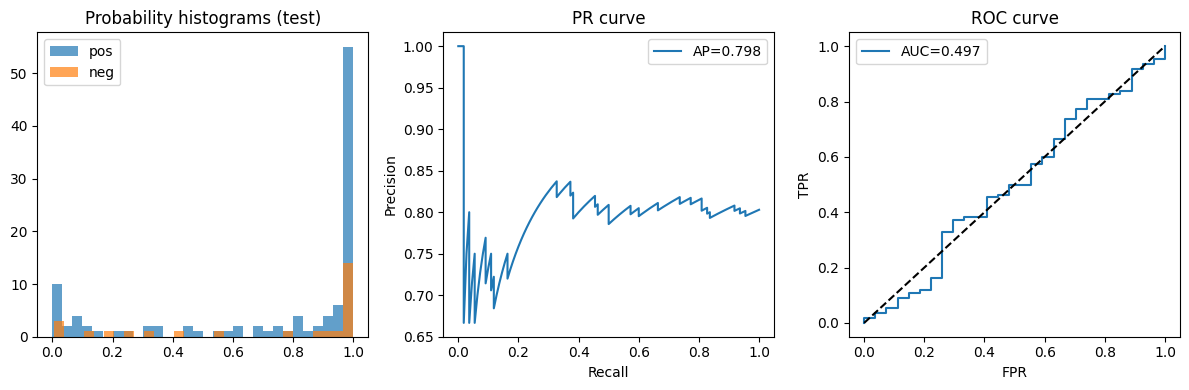

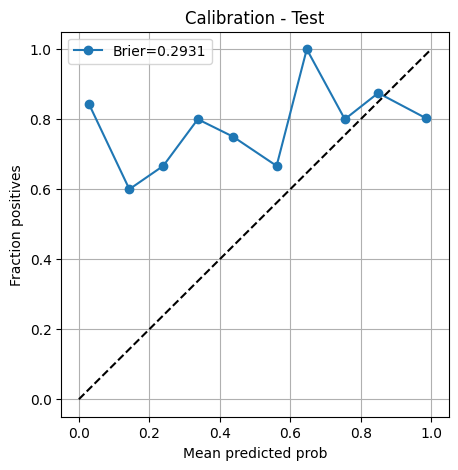

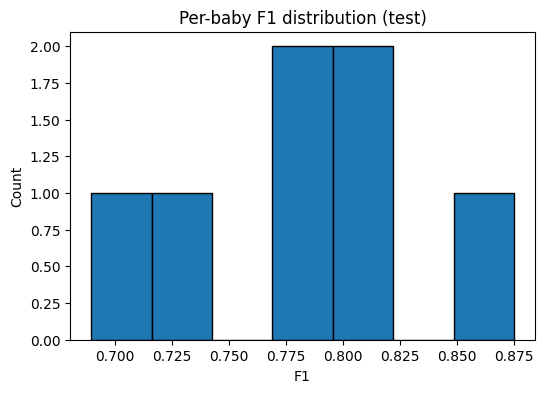

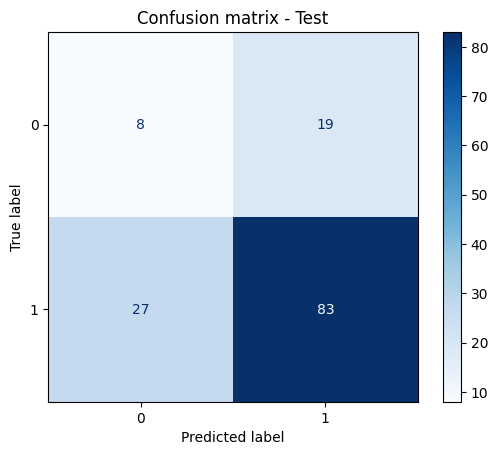

In [11]:

# %% Plots: prob hist, PR, ROC, calibration and per-baby histogram
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(probs_test[labels_test==1], bins=30, alpha=0.7, label='pos')
plt.hist(probs_test[labels_test==0], bins=30, alpha=0.7, label='neg')
plt.title('Probability histograms (test)')
plt.legend()

plt.subplot(1,3,2)
precision, recall, thr = precision_recall_curve(labels_test, probs_test)
ap = average_precision_score(labels_test, probs_test)
plt.plot(recall, precision, label=f'AP={ap:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR curve'); plt.legend()

plt.subplot(1,3,3)
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(labels_test, probs_test)
roc_auc = roc_auc_score(labels_test, probs_test)
plt.plot(fpr, tpr, label=f'AUC={roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC curve'); plt.legend()
plt.tight_layout()
plt.show()

# Calibration
frac_pos, mean_pred = calibration_curve(labels_test, probs_test, n_bins=10)
brier = brier_score_loss(labels_test, probs_test)
plt.figure(figsize=(5,5))
plt.plot(mean_pred, frac_pos, marker='o', label=f'Brier={brier:.4f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('Mean predicted prob'); plt.ylabel('Fraction positives'); plt.title('Calibration - Test')
plt.legend(); plt.grid(True)
plt.show()

# Per-baby histogram
if not per_baby_df.empty:
    plt.figure(figsize=(6,4))
    plt.hist(per_baby_df['f1'].dropna(), bins=min(20, len(per_baby_df)), edgecolor='black')
    plt.title('Per-baby F1 distribution (test)')
    plt.xlabel('F1'); plt.ylabel('Count'); plt.show()

# Confusion matrix plot
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap=plt.cm.Blues)
plt.title('Confusion matrix - Test')
plt.show()